# ML Zoomcamp Midterm Project

### Data Preparation

In [12]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# 2. Load data
df = pd.read_csv('../data/bank_transactions_data_2.csv')

# 3. Quick overview
print(df.shape)
df.info()
df.head()
df.describe()
df.isnull().sum()

(2512, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalanc

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [9]:
# 5. Feature engineering (create 'is_fraud')
df['is_fraud'] = (
    (df['TransactionAmount'] > 0.6 * df['AccountBalance']) |
    (df['LoginAttempts'] > 3) |
    (df['TransactionDuration'] < 20)
).astype(int)

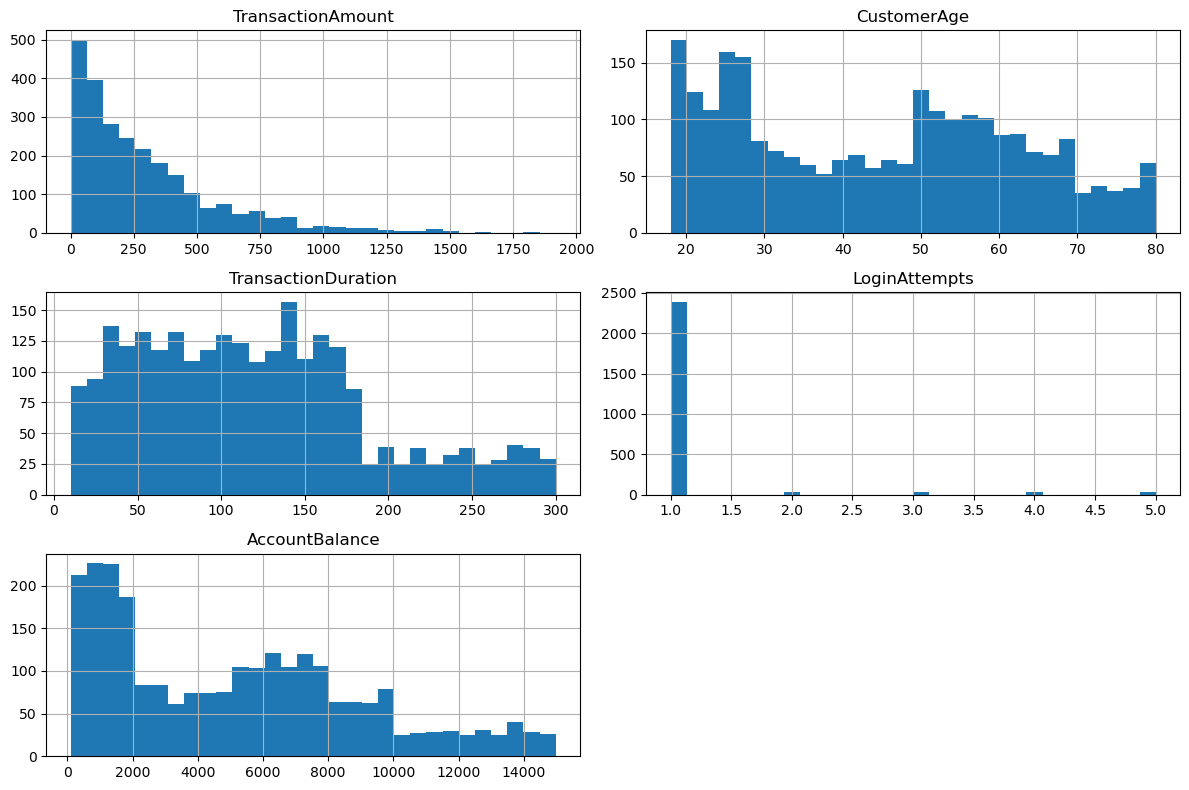

ValueError: Could not interpret value `is_fraud` for `x`. An entry with this name does not appear in `data`.

In [14]:
# Histogram for numerical features
df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

# Boxplot for TransactionAmount by fraud flag
sns.boxplot(x="is_fraud", y="TransactionAmount", data=df)
plt.title("Transaction Amount by Fraud Status")
plt.show()

Text(0.5, 1.0, 'Fraud vs Non-Fraud Distribution')

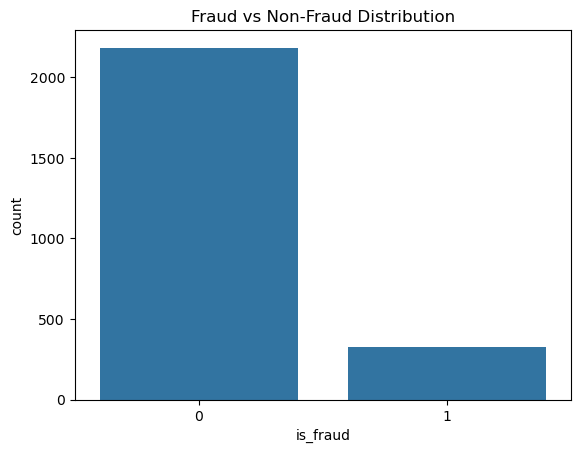

In [10]:
# 6. Distribution plot
sns.countplot(x='is_fraud', data=df)
plt.title('Fraud vs Non-Fraud Distribution')

In [15]:
# Compare averages between fraud and non-fraud
df.groupby("is_fraud").mean(numeric_only=True)

# Fraud rate by Transaction Channel
fraud_by_channel = df.groupby("TransactionChannel")["is_fraud"].mean().sort_values(ascending=False)
fraud_by_channel.plot(kind="bar", title="Fraud Rate by Channel")
plt.ylabel("Fraud Rate")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


KeyError: 'is_fraud'

In [11]:
# 7. Save processed version
df.to_csv('../data/processed_transactions.csv', index=False)